In [13]:
%pip install geopandas shapely fiona pyproj rtree
%pip install rasterio folium osmnx

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Geopandas

In [14]:
import geopandas as gpd

# Load a shapefile or GeoJSON
gdf = gpd.read_file("/Users/chibangnguyen/Documents/thuhoach.nckh/ipynb/data/ne_10m_land/ne_10m_land.shp")
print(gdf.head())

  featurecla  scalerank  min_zoom  \
0       Land        0.0       0.0   
1       Land        6.0       5.0   
2       Land        5.0       3.0   
3       Land        6.0       6.0   
4       Land        5.0       4.0   

                                            geometry  
0  MULTIPOLYGON (((-0.00029 -71.49903, 0.01555 -7...  
1  MULTIPOLYGON (((166.13697 -50.86435, 166.20525...  
2  MULTIPOLYGON (((-78.78897 -33.60906, -78.78038...  
3  MULTIPOLYGON (((163.98512 -20.04762, 163.98609...  
4  MULTIPOLYGON (((134.70737 -6.58904, 134.72006 ...  


EPSG:4326
0     MULTIPOLYGON (((-0.00029 -71.49903, 0.01555 -7...
1     MULTIPOLYGON (((166.13697 -50.86435, 166.20525...
2     MULTIPOLYGON (((-78.78897 -33.60906, -78.78038...
3     MULTIPOLYGON (((163.98512 -20.04762, 163.98609...
4     MULTIPOLYGON (((134.70737 -6.58904, 134.72006 ...
5     MULTIPOLYGON (((-80.05989 -2.66277, -80.01452 ...
6     MULTIPOLYGON (((81.87599 7.09195, 81.87843 7.0...
7     MULTIPOLYGON (((55.018 24.97651, 55.0158 24.97...
8     MULTIPOLYGON (((134.68979 33.82807, 134.72203 ...
9     MULTIPOLYGON (((14.76303 68.49486, 14.71746 68...
10    POLYGON ((-0.00479 -0.00439, -0.00479 0.00482,...
Name: geometry, dtype: geometry


<Axes: >

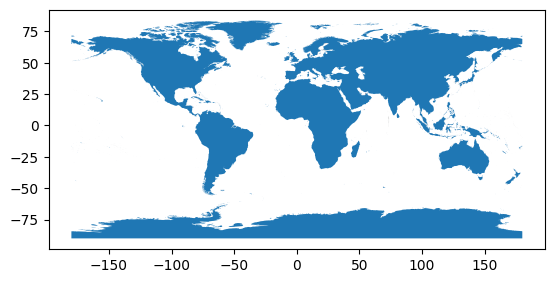

In [15]:
print(gdf.crs)           # Coordinate Reference System (e.g., EPSG:4326)
print(gdf.geometry)      # View geometry column (points, lines, polygons)
gdf.plot()               # Plot using matplotlib

In [16]:
gdf = gdf.to_crs(epsg=3857)  # Convert to Web Mercator

In [17]:
from shapely.geometry import Point

point = Point(106.7, 10.7)
gdf[gdf.contains(point)]

,featurecla,scalerank,min_zoom,geometry
10,Null island,100.0,100.0,"POLYGON ((-533.158 -488.685, -533.158 536.215,..."


<Axes: >

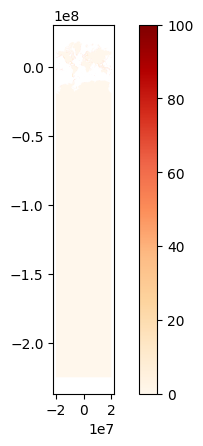

In [18]:
gdf.plot(column='scalerank', cmap='OrRd', legend=True)

In [19]:
import folium

m = folium.Map(location=[10.7, 106.7], zoom_start=12)
folium.GeoJson(gdf).add_to(m)
m.save("map.html")

# OSmnx

In [64]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# 1. Get a street network
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')


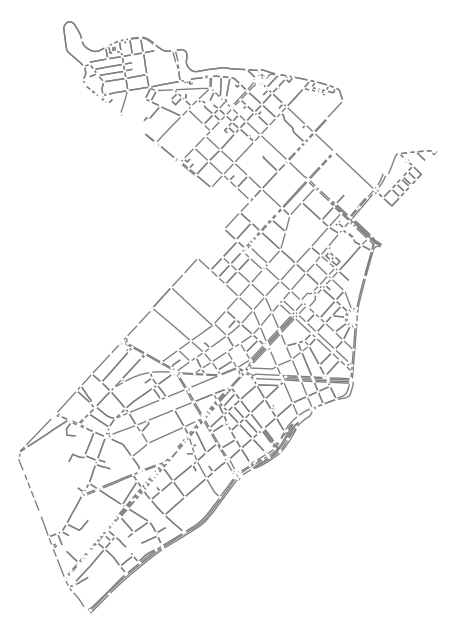

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [65]:
ox.plot_graph(G, bgcolor='white', node_size=5, edge_color='gray')

In [66]:

# 2. Find nearest nodes to your start/end coordinates
orig_point = (10.75998,106.68634)
dest_point = (10.78462,106.70746)

orig = ox.distance.nearest_nodes(G, X=orig_point[1], Y=orig_point[0])
dest = ox.distance.nearest_nodes(G, X=dest_point[1], Y=dest_point[0])


In [67]:
k_paths = ox.routing.k_shortest_paths(G, orig, dest, k=1, weight='length')

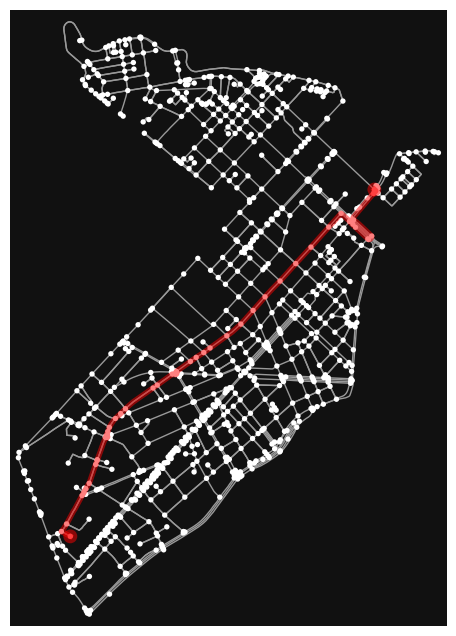

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [68]:
ox.plot_graph_routes(G, k_paths)